In [1]:
from functools import partial

from superfv import HydroSolver, ics, BC

import matplotlib.pyplot as plt
import numpy as np

In [2]:
nu = 1e-4
cs = 1e-4

ic = partial(
    ics.velocity_shear_diffusion,
    v0=1.0,
    sigma0=0.1,
    x0=0.5,
    nu=nu,
    rho0=1.0,
    kappa=15.0,
    iso_cs=cs,
)

sim = HydroSolver(
    ic=ic,
    nu=nu,
    nx=64,
    p=7,
    CFL=0.5,
    bcx=(BC.IC, BC.IC),
    isothermal=True,
    iso_cs=cs,
)

In [3]:
sim.run(40.0)

SuperFV: 66 steps | t=4.00e+01/4.00e+01, dt=3.27e-01 | rho_min=3.48e-07 | E_cons=2.75e-08 | wall=1.20e-01s (done)


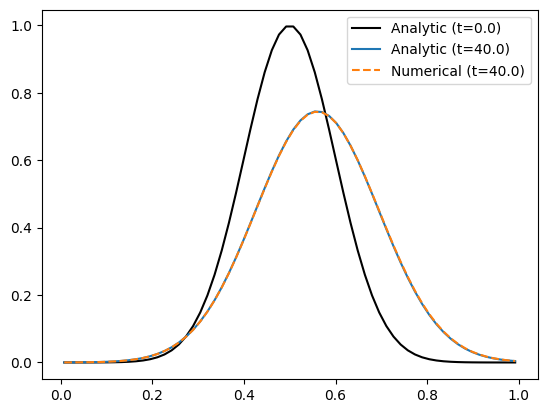

In [4]:
fig, ax = plt.subplots()

ax.plot(
    sim.mesh.centers[0],
    ic(sim.idx, *sim.mesh.Centers, 0.0, xp=np)[sim.idx("vy"), :, 0, 0],
    "k",
    label="Analytic (t=0.0)",
)
ax.plot(
    sim.mesh.centers[0],
    ic(sim.idx, *sim.mesh.Centers, sim.t, xp=np)[sim.idx("vy"), :, 0, 0],
    label=f"Analytic (t={sim.t})",
)
ax.plot(
    sim.mesh.centers[0],
    sim.snapshot_history[-1].w[sim.idx("vy"), :, 0, 0],
    "--",
    label=f"Numerical (t={sim.t})",
)

ax.legend()